<a href="https://colab.research.google.com/github/TimothyKeng/Timothy_INFO4670_Falls2026/blob/main/Assignment3_AssociationRuleMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [61]:
%pip install pandas matplotlib mlxtend networkx

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

In [63]:
from google.colab import files
uploaded = files.upload()

Saving bread_basket-2.csv to bread_basket-2 (2).csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [64]:
transactions = pd.read_csv('bread_basket-2.csv')
transactions
transactions.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [65]:
transactions.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

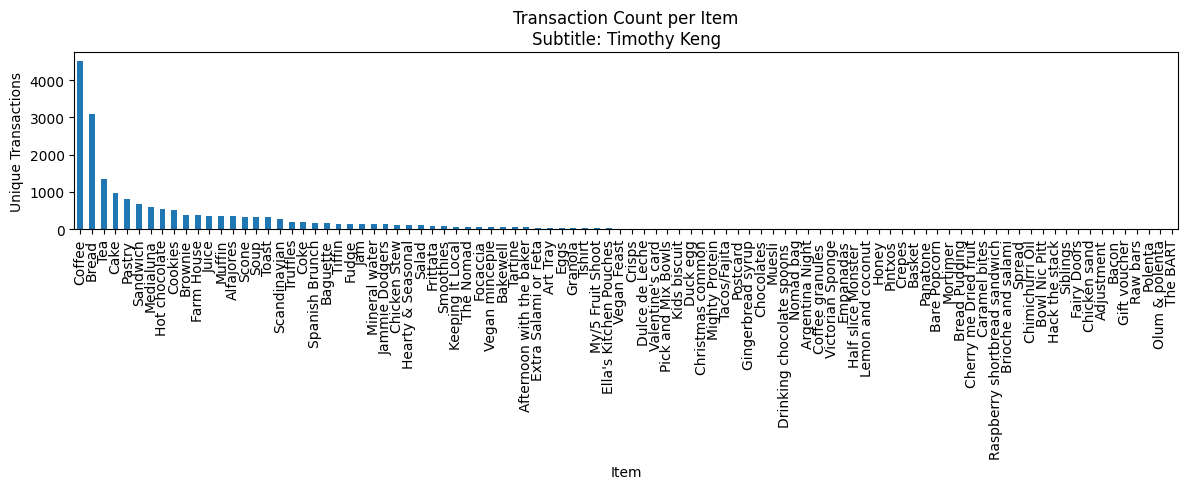

In [66]:
subtitle = "Timothy Keng"
item_counts = (transactions.groupby('item')['transaction'].nunique().sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [67]:
specific_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
item_counts[specific_items]

,transaction
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [68]:
list_of_transactions= transactions.groupby('transaction')['item'].apply(list)
te= TransactionEncoder()
te_ary= te.fit(list_of_transactions).transform(list_of_transactions)
df_encoded= pd.DataFrame(te_ary, columns=te.columns_).astype(bool)

freq_fp= fpgrowth(df_encoded, min_support= .02, use_colnames= True)
freq_fp.sort_values('support', ascending= False)

,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Coffee, Bread)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Coffee, Cake)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [69]:
rules_low_threshold = association_rules(freq_fp, metric='confidence', min_threshold=0.3)

print(f"Number of rules with min_threshold = 0.3: {len(rules_low_threshold)}")
display(rules_low_threshold[['antecedents','consequents','support','confidence','lift']].sort_values('confidence', ascending=False))

Number of rules with min_threshold = 0.3: 10


,antecedents,consequents,support,confidence,lift
9,(Toast),(Coffee),0.023666,0.704403,1.472431
4,(Medialuna),(Coffee),0.035182,0.569231,1.189878
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
6,(Juice),(Coffee),0.020602,0.534247,1.116750
8,(Sandwich),(Coffee),0.038246,0.532353,1.112792
7,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Cookies),(Coffee),0.028209,0.518447,1.083723
0,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311
5,(Tea),(Coffee),0.049868,0.349630,0.730840
3,(Pastry),(Bread),0.029160,0.338650,1.034977


## 5) Rule Subgraph

In [70]:
N = 200
basket = (transactions.groupby('transaction')['item'].apply(list)
                 .reset_index()
                 .sort_values('transaction')
                 .head(N)['item']
                 .tolist())

te_b = TransactionEncoder()
oht_b = pd.DataFrame(te_b.fit(basket).transform(basket), columns=te_b.columns_).astype(bool)
oht_b.shape

(200, 30)

In [71]:
minsup = 0.01
minconf = 0.3

freq_b = fpgrowth(oht_b, min_support=minsup, use_colnames=True)
rules_b = association_rules(freq_b, metric='confidence', min_threshold=minconf)
rules_b[['antecedents','consequents','support','confidence','lift']].sort_values(['lift','confidence'], ascending=False).head(15)

,antecedents,consequents,support,confidence,lift
19,(Mineral water),(Hearty & Seasonal),0.015,0.500000,9.090909
18,(Tartine),"(Coffee, Tea)",0.015,0.500000,7.692308
2,(Hot chocolate),(Cookies),0.010,0.400000,6.666667
29,(Frittata),(Hearty & Seasonal),0.010,0.333333,6.060606
35,(Soup),(Hearty & Seasonal),0.015,0.333333,6.060606
33,(Frittata),"(Coffee, Tea)",0.010,0.333333,5.128205
26,(Victorian Sponge),(Tea),0.015,0.750000,3.947368
16,"(Coffee, Tartine)",(Tea),0.015,0.600000,3.157895
23,"(Juice, Coffee)",(Pastry),0.010,0.333333,2.898551
8,(Medialuna),(Pastry),0.020,0.307692,2.675585


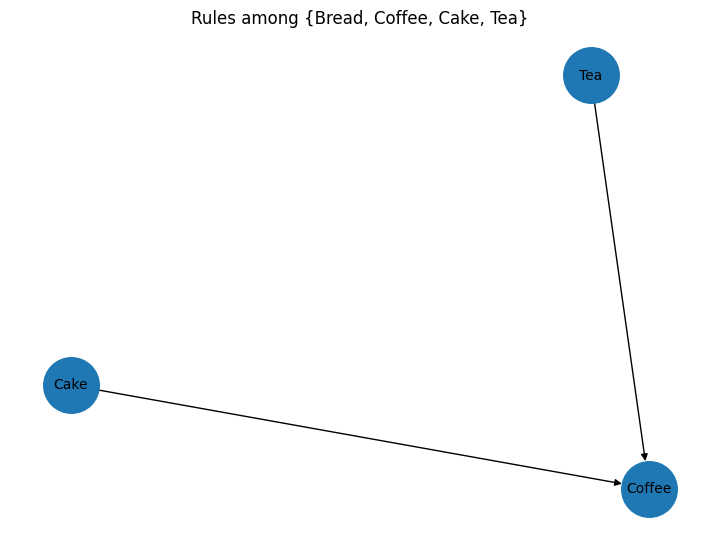

In [72]:
import networkx as nx

focus = {'Bread','Coffee','Cake','Tea'}
sub = rules_b[
    rules_b['antecedents'].apply(lambda s: s.issubset(focus)) &
    rules_b['consequents'].apply(lambda s: s.issubset(focus))
].copy()

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake, Tea}")
plt.show()

## 6) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

About 1% of all transactions contain cofee, cake, and bread together. Of the customers who bought both coffee and cake, about 18.3% of them also bought
bread. Since the lift is about .56, the combo of coffee and cake doesn't have a positive association with bread. Of the customers who buy coffee and cake, less than average are likely to buy bread, so it wouldn't be a strong combination.

In [73]:
support = (
    df_encoded["Coffee"] &
    df_encoded["Cake"] &
    df_encoded["Bread"]
).mean()

coffee_cake_support = (
    df_encoded["Coffee"] &
    df_encoded["Cake"]
).mean()

confidence = support / coffee_cake_support

bread_support = df_encoded["Bread"].mean()

lift = confidence / bread_support

print(f"Support: {support:.2%}")
print(f"Confidence: {confidence:.2%}")
print(f"Lift: {lift:.2f}")

Support: 1.00%
Confidence: 18.34%
Lift: 0.56
